# **Mini Exploratory Data Analysis (EDA) on the Titanic dataset Task 3**

**Author:** Preethi Ann

**Internship:** Data Science/Analysis with Python Internship

**Dataset:** Titanic Dataset (`train.csv`)

## **objective**
Perform a Mini Exploratory Data Analysis (EDA) on the Titanic dataset with more advanced techniques than Task 2. This involves cleaning the data through imputation (handling missing Age values, dropping irrelevant columns like Cabin), and using groupby operations to uncover deeper insights — survival rates by age group, embarkation port, and family size. The task also requires creating multiple visualizations (histogram, correlation heatmap, bar plots) to effectively communicate findings. Overall, it builds core data science skills: EDA, data cleaning, and storytelling with data.

## **Importing Libraries**


In [1]:
# Importing required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

## **Loading Dataset**

In [2]:
df = pd.read_csv("train.csv")

In [3]:
# Preview the first few rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **Understand the Dataset**

In [4]:
# Check the number of rows and columns
df.shape

(891, 12)

#### **OBSERVATION**

The Titanic dataset contains 891 rows (passengers) and 12 columns (features). Each row represents one passenger and each column contains specific information such as age, gender, fare, survival status, etc.

In [5]:
# Check column data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


#### **OBSERVATION**

The dataset contains both numerical and categorical variables. Some columns, such as Age, Cabin, and Embarked, have missing values that need to be handled before analysis.

In [6]:
# Summary statistics for numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### **OBSERVATION**

The summary statistics show that passenger ages range from infants to elderly individuals. Fare values vary widely, indicating different ticket classes. The dataset provides useful numerical information for further analysis.

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### **OBSERVATION**

The dataset contains missing values in the Age, Cabin, and Embarked columns. The Cabin column has a large number of missing values (687), making it less useful for analysis. The Age column has 177 missing values, which will be filled using the mean age to retain all passenger records.

## **Filling missing values of Age and Embarked with mean.**

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [9]:
df['Age'].isnull().sum()

np.int64(0)

#### **Observation**

Missing values in the Age column were successfully replaced with the mean age of all passengers. After imputation, the output of df['Age'].isnull().sum() is 0, confirming that there are no missing values remaining in the Age column. This ensures the dataset is complete and ready for further analysis without losing any records.

In [10]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
df['Embarked'].isnull().sum()

np.int64(0)

#### **OBSERVATION**

The missing values in the Embarked column were filled using the most frequently occurring embarkation port (mode). This is a common technique for handling missing values in categorical variables.

In [12]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### **Dropping the cabin column**

In [13]:
df.drop('Cabin', axis=1, inplace=True)

In [14]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

#### **Observation**

The Cabin column was dropped because it contained a large number of missing values (687 out of 891 records, approximately 77% of the data). Since most of the information was unavailable, the column was considered less useful for analysis. Removing it improved the overall quality and reliability of the dataset.

In [15]:
df.isnull().sum()
#FINAL CHECK FOR MISSING VALUES

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

#### **OBSERVATION**

After data cleaning, the dataset contains no missing values in the remaining columns. The data is now complete and ready for exploratory data analysis (EDA) and visualization.

# **Analysis Questions**

### **1. Survival rate by Age Group**


In [16]:
# Create age bins and compute survival rate for each age group
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_group_survival = df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100
age_group_survival

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

**ANS**
| Age Group   | Survival Rate (%) |
| ----------- | ----------------: |
| Child       |            57.97% |
| Teen        |            42.86% |
| Young Adult |            35.33% |
| Adult       |            40.00% |
| Senior      |            22.73% |

**Observation**

Children had the highest survival rate (57.97%), indicating they were given higher priority during rescue operations. Senior passengers had the lowest survival rate (22.73%), while adults and young adults showed moderate survival rates.


### **2. Survival Rate by Embarkation Port**

In [17]:
# Compute survival rate for each embarkation port
port_survival = df.groupby('Embarked')['Survived'].mean() * 100
port_survival

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

**ANS**
| Embarkation Port | Survival Rate (%) |
| ---------------- | ----------------: |
| C (Cherbourg)    |            55.36% |
| Q (Queenstown)   |            38.96% |
| S (Southampton)  |            33.90% |


**Observation**

Passengers who boarded at Cherbourg (C) had the highest survival rate (55.36%). Passengers from Southampton (S) had the lowest survival rate (33.90%), suggesting that embarkation port was associated with differences in survival.

### **3. Survival Rate by Family Size (SibSp + Parch)**

**ANS**
| Family Size | Survival Rate (%) |
| ----------- | ----------------: |
| 0           |        **30.35%** |
| 1           |        **55.28%** |
| 2           |        **57.84%** |
| 3           |        **72.41%** |
| 4           |        **20.00%** |
| 5           |        **13.64%** |
| 6           |        **33.33%** |
| 7           |         **0.00%** |
| 10          |         **0.00%** |

**Observation**

Passengers traveling with a family size of 3 had the highest survival rate (72.41%). Those traveling alone had a lower survival rate (30.35%), while passengers in very large families (7 and 10 members) had 0% survival, indicating that larger family groups faced greater difficulty during evacuation.

### **Overall Analysis**

The analysis shows that survival on the Titanic was influenced by age, embarkation port, and family size. Children had the highest survival rate, passengers boarding at Cherbourg (C) survived more often than those from other ports, and passengers traveling with small families (especially a family size of 3) had the best survival outcomes. These findings demonstrate the value of exploratory data analysis (EDA) in identifying meaningful patterns within the dataset.

## **Visualizations**

### **1. Age Distribution (Histogram)**

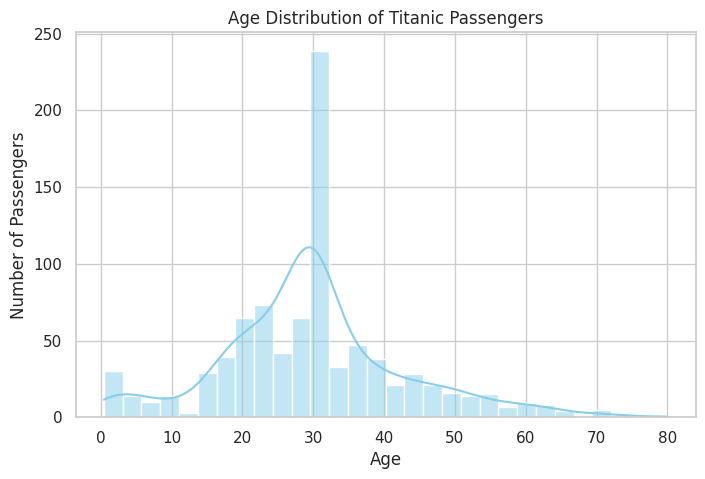

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color='SKYBLUE')
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

#### **Observation**

The histogram shows that most passengers were between 20 and 40 years of age. There were relatively fewer children and senior citizens on board. The distribution is slightly right-skewed, indicating a smaller number of older passengers.

### **2. Heatmap of Correlations**

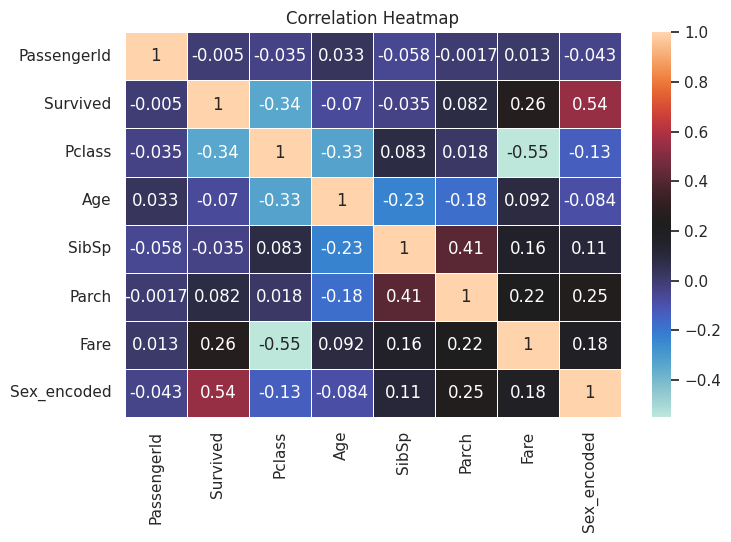

In [19]:
plt.figure(figsize=(8,5))

# Encode Sex as numeric so it can be included in the correlation matrix
numeric = df.select_dtypes(include='number').copy()
numeric['Sex_encoded'] = df['Sex'].map({'male': 0, 'female': 1})

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='icefire',
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

#### **Observation**

The heatmap shows that Fare has a positive correlation with Survived, while Pclass has a negative correlation with Survived. Sex was encoded numerically (male=0, female=1) so it could be included in the matrix, and it shows a strong positive correlation with Survived, confirming that being female was one of the biggest factors in survival. Most other numerical features have weak correlations, indicating a smaller linear relationship with passenger survival.

Passenger class, fare, and sex were the strongest factors associated with survival.

### **3. Survival Rate by Age Group (Bar Plot)**

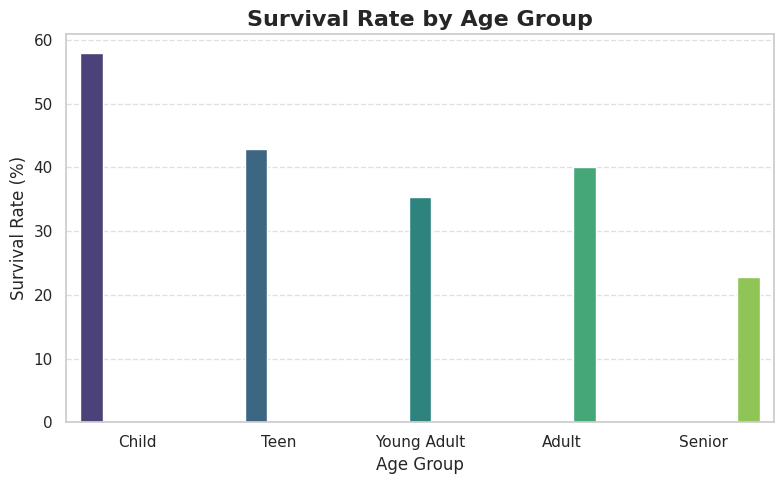

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=age_group_survival.index,
    y=age_group_survival.values,
    hue=age_group_survival.index,
    palette="viridis",
    legend=False
)

plt.title("Survival Rate by Age Group", fontsize=16, fontweight='bold')
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Survival Rate (%)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### **Observation**

The bar plot confirms that children had the highest survival rate, while seniors had the lowest, with a general downward trend in survival rate as age group increases.

### **4. Survival Rate by Embarkation Port (Bar Plot)**

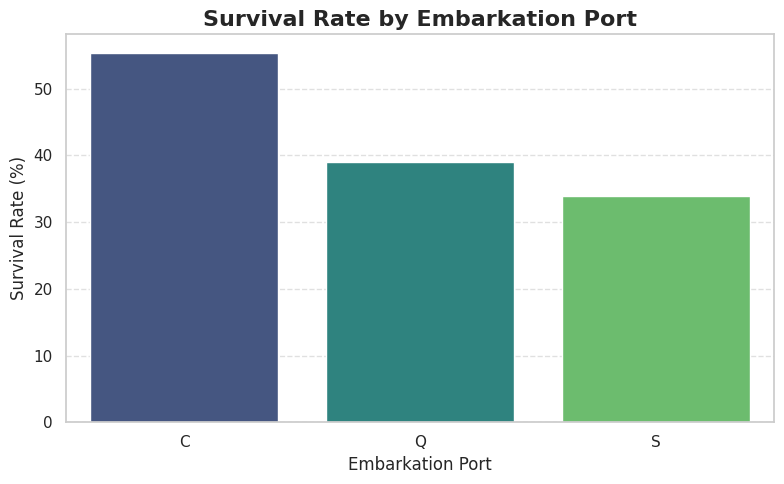

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=port_survival.index,
    y=port_survival.values,
    hue=port_survival.index,
    palette="viridis",
    legend=False
)

plt.title("Survival Rate by Embarkation Port", fontsize=16, fontweight='bold')
plt.xlabel("Embarkation Port", fontsize=12)
plt.ylabel("Survival Rate (%)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### **Observation**

Passengers who boarded at Cherbourg had a noticeably higher survival rate than those from Queenstown or Southampton, consistent with the earlier groupby results.

### **5. Survival by Family Size (Bar Plot)**

In [22]:
# Create FamilySize column
df['FamilySize'] = df['SibSp'] + df['Parch']

# Calculate survival rate by family size
family_survival = df.groupby('FamilySize')['Survived'].mean() * 100
family_survival



FamilySize
0     30.353818
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64

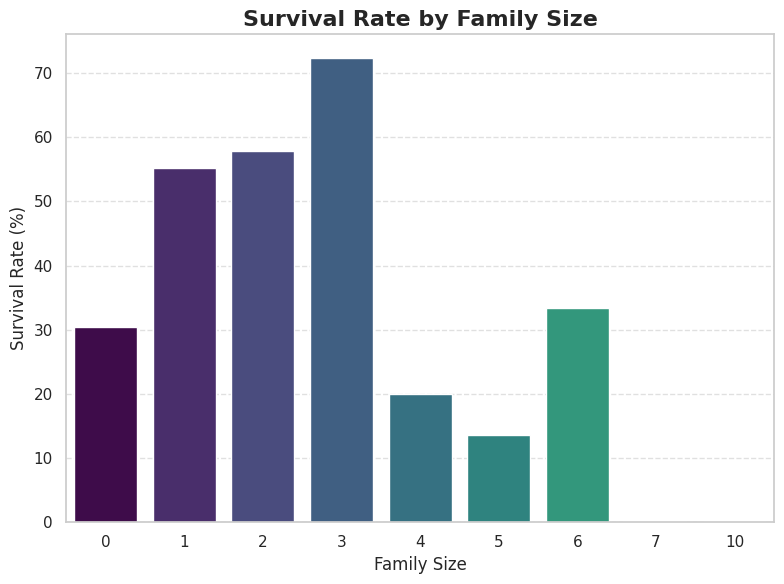

In [23]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=family_survival.index,
    y=family_survival.values,
    hue=family_survival.index,
    palette="viridis",
    legend=False
)

plt.title("Survival Rate by Family Size", fontsize=16, fontweight='bold')
plt.xlabel("Family Size", fontsize=12)
plt.ylabel("Survival Rate (%)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### **Observation**

The highest survival rate was observed among passengers traveling with a family size of 3. Passengers traveling alone had a lower survival rate, while those traveling in very large families had the lowest survival rates.

Traveling with a small family improved the chances of survival, whereas traveling in large family groups reduced survival probability.

### **Final Overall Conclusion**

The exploratory data analysis revealed several important patterns in the Titanic dataset. Data cleaning ensured reliable analysis by handling missing values and removing irrelevant columns. Visualizations showed that most passengers were young adults, passenger class and fare were strongly related to survival, and passengers traveling with small families had better survival chances than those traveling alone or in large families. Overall, this analysis demonstrates how EDA helps uncover meaningful insights from real-world datasets using Python, Pandas, Matplotlib, and Seaborn.